In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your file
df = pd.read_csv("monthly-milk-production-pounds.csv")

# Preview
df.head()

,Month,Monthly milk production: pounds per cow. Jan 62 ? Dec 75
0,1962-01,589.0
1,1962-02,561.0
2,1962-03,640.0
3,1962-04,656.0
4,1962-05,727.0


In [2]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 2 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Month                                                     169 non-null    object 
 1   Monthly milk production: pounds per cow. Jan 62 ? Dec 75  168 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.8+ KB


Index(['Month', 'Monthly milk production: pounds per cow. Jan 62 ? Dec 75'], dtype='object')

Rename column

In [3]:
df.columns = ['Date', 'Milk_Production']

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

remove invalid dates

In [5]:
df = df.dropna(subset=['Date'])

In [6]:
df['Milk_Production'] = pd.to_numeric(df['Milk_Production'], errors='coerce')

handle missing values

In [7]:
df = df.dropna()

remove duplicate

In [8]:
df = df.drop_duplicates()

 Sort Data

In [9]:
df = df.sort_values(by='Date')


Feature Engineering

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


In [11]:
df['Rolling_Avg'] = df['Milk_Production'].rolling(window=12).mean()

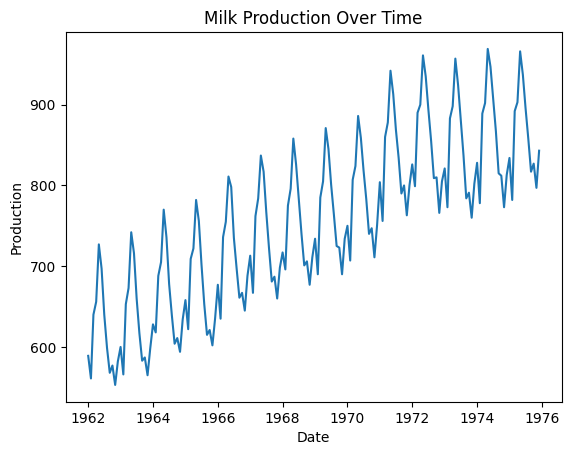

In [12]:
plt.figure()
plt.plot(df['Date'], df['Milk_Production'])
plt.title("Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

year wise total production

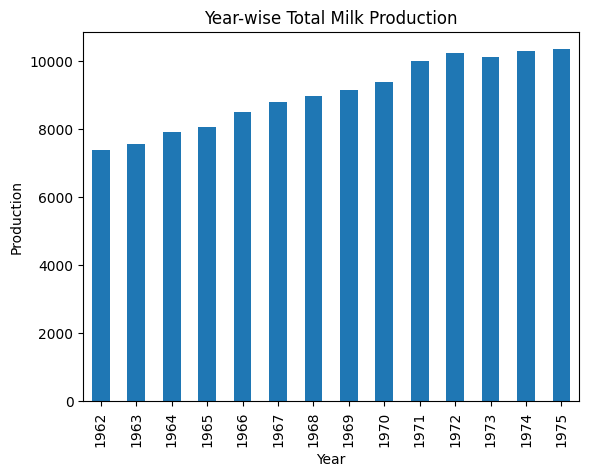

In [13]:
yearly = df.groupby('Year')['Milk_Production'].sum()

plt.figure()
yearly.plot(kind='bar')
plt.title("Year-wise Total Milk Production")
plt.ylabel("Production")
plt.show()

month wise comparison

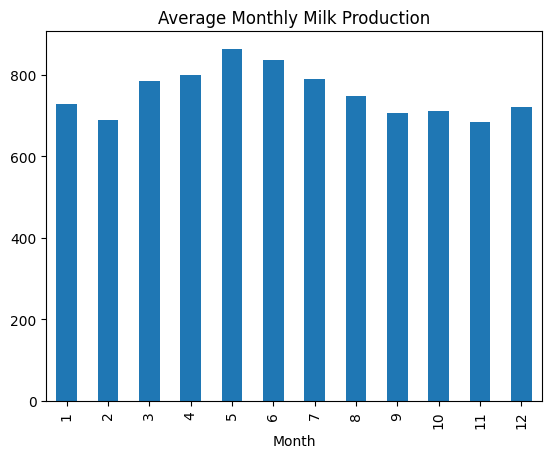

In [14]:
monthly = df.groupby('Month')['Milk_Production'].mean()

plt.figure()
monthly.plot(kind='bar')
plt.title("Average Monthly Milk Production")
plt.show()

heatmap year vs month

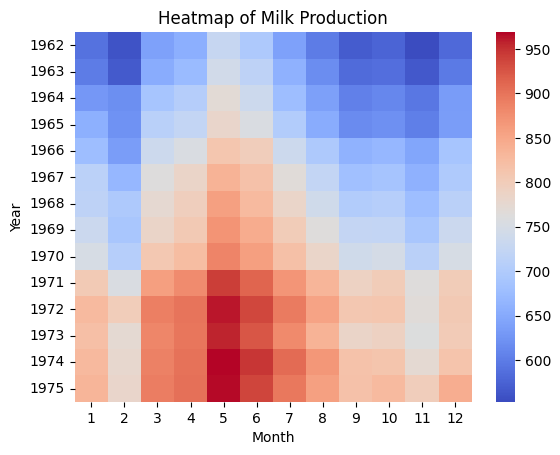

In [15]:
pivot = df.pivot_table(values='Milk_Production', index='Year', columns='Month')

plt.figure()
import seaborn as sns
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap of Milk Production")
plt.show()

growth rate analysis

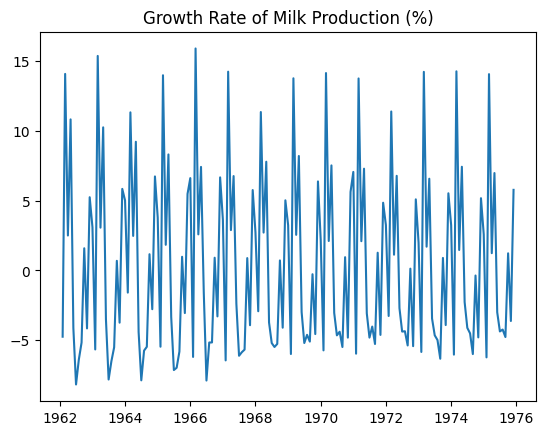

In [16]:
df['Growth_%'] = df['Milk_Production'].pct_change() * 100

plt.figure()
plt.plot(df['Date'], df['Growth_%'])
plt.title("Growth Rate of Milk Production (%)")
plt.show()

distribution plot

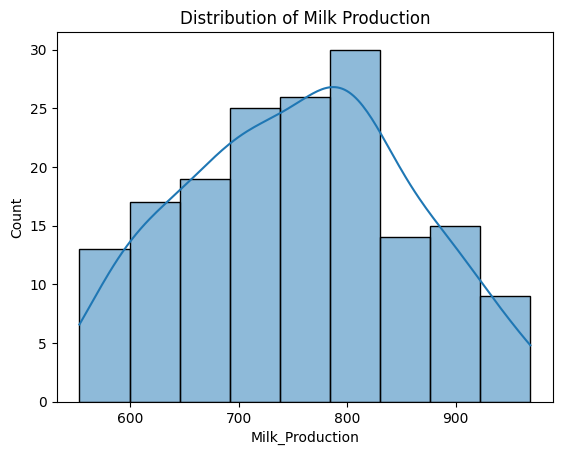

In [17]:
plt.figure()
sns.histplot(df['Milk_Production'], kde=True)
plt.title("Distribution of Milk Production")
plt.show()

box plot

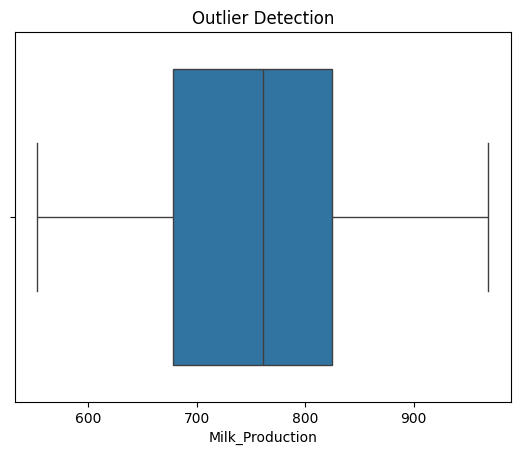

In [18]:
plt.figure()
sns.boxplot(x=df['Milk_Production'])
plt.title("Outlier Detection")
plt.show()

year comparison

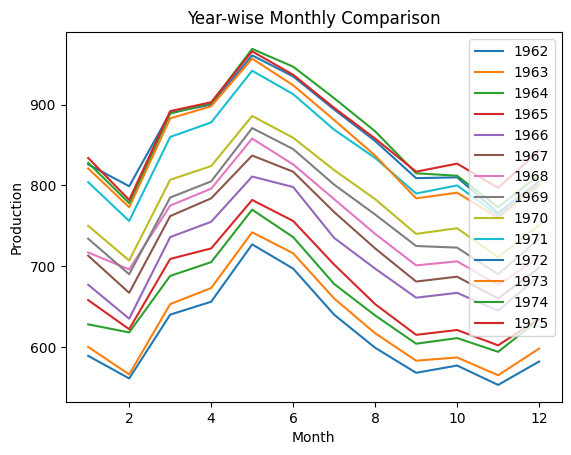

In [19]:
for year in df['Year'].unique():
    temp = df[df['Year'] == year]
    plt.plot(temp['Month'], temp['Milk_Production'], label=year)

plt.legend()
plt.title("Year-wise Monthly Comparison")
plt.xlabel("Month")
plt.ylabel("Production")
plt.show()

correlation heatmap

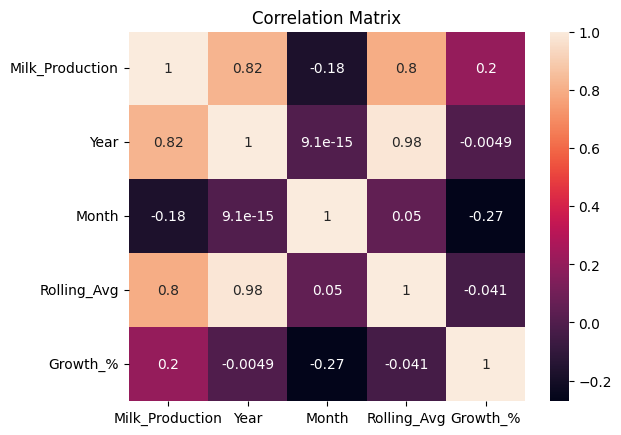

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

save cleaned file

In [21]:
df.to_csv("cleaned_milk_production.csv", index=False)

In [22]:
print(df.head())
print(df.info())

        Date  Milk_Production  Year  Month  Rolling_Avg   Growth_%
0 1962-01-01            589.0  1962      1          NaN        NaN
1 1962-02-01            561.0  1962      2          NaN  -4.753820
2 1962-03-01            640.0  1962      3          NaN  14.081996
3 1962-04-01            656.0  1962      4          NaN   2.500000
4 1962-05-01            727.0  1962      5          NaN  10.823171
<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             168 non-null    datetime64[ns]
 1   Milk_Production  168 non-null    float64       
 2   Year             168 non-null    int32         
 3   Month            168 non-null    int32         
 4   Rolling_Avg      157 non-null    float64       
 5   Growth_%         167 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int32(2)
memory usage: 7.9 KB
None
